# Probe: Whisper · MFA · CREPE

Systematic per-track inspection of the three main pipeline components:

| Tool | Task | What we inspect |
|------|------|-----------------|
| **Whisper** | ASR transcription | hypothesis text, WER vs ground-truth |
| **MFA** | Forced alignment | word/phone time boundaries, diff vs original TextGrid |
| **CREPE** | Pitch (F0) tracking | pitch curve, voiced ratio, F0 stats |

Three experiments:
- **Part 1** — deep dive on one single track (first available technique with a TextGrid)
- **Part 2** — one track per (technique × group) combination, side-by-side comparison
- **Part 3** — two tracks per (technique × group) combination, aggregate statistics & visualisations

Track lists are built dynamically from whatever data is on disk — missing techniques are silently skipped.

In [1]:
import sys, warnings, os, importlib.util
from pathlib import Path

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))

# evict stale torch-ecosystem stubs before importing torch
_TORCH_PKGS = ('torch', 'torchaudio', 'torchvision', 'torchelastic', 'torchtext')
for _k in [k for k in sys.modules if any(k == p or k.startswith(p + '.') for p in _TORCH_PKGS)]:
    del sys.modules[_k]
del _TORCH_PKGS

# patch find_spec: auto-evict __spec__=None stubs (IPython re-injects them each cell)
_orig_find_spec = importlib.util.find_spec
def _safe_find_spec(name, package=None, _orig=_orig_find_spec):
    if name in sys.modules and getattr(sys.modules[name], '__spec__', None) is None:
        del sys.modules[name]
    try:
        return _orig(name, package)
    except ValueError:
        return None
importlib.util.find_spec = _safe_find_spec
del _orig_find_spec, _safe_find_spec

# patch os.path.exists: return False for non-path args instead of crashing
_orig_exists = os.path.exists
def _safe_exists(p, _orig=_orig_exists):
    if not isinstance(p, (str, bytes, os.PathLike)):
        return False
    return _orig(p)
os.path.exists = _safe_exists
del _orig_exists, _safe_exists

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Audio

from alt.dataset import GTSingerAdapter
from alt.asr import get_asr_model
from alt.alignment import MFAAligner, parse_textgrid
from alt.pitch import CrepeExtractor
from alt.audio import load_audio, TARGET_SR
from alt.text import clean_text, SKIP_LABELS

DATA_ROOT = REPO_ROOT / 'data' / 'GTSinger' / 'English'
WORK_DIR  = REPO_ROOT / 'data' / '_work' / 'notebook_probe'
WORK_DIR.mkdir(parents=True, exist_ok=True)

DEVICE     = 'cuda'
WHISPER_ID = 'whisper_small'
MFA_BIN    = '/home/antonello/miniforge3/envs/aligner/bin/mfa'
CREPE_CAP  = 'tiny'

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Setup done.')

Setup done.


## Load dataset & select tracks


In [2]:
# Load all GTSinger English utterances
adapter  = GTSingerAdapter(root=DATA_ROOT)
all_utts = adapter.list_utterances()
print(f'Total utterances: {len(all_utts)}')

inv = pd.DataFrame([
    {'singer': u.singer_id, 'technique': u.technique,
     'group': u.group, 'has_tg': u.textgrid_path is not None}
    for u in all_utts
])
summary = inv.groupby(['technique', 'group']).agg(
    count=('singer', 'count'), with_textgrid=('has_tg', 'sum')
).reset_index()
display(summary)


Total utterances: 2153


,technique,group,count,with_textgrid
0,breathy,control,225,158
1,breathy,speech,225,158
2,breathy,technique,225,158
3,glissando,control,108,56
4,glissando,speech,99,47
5,glissando,technique,99,47
6,mixed_falsetto,control,306,177
7,mixed_falsetto,speech,289,160
8,mixed_falsetto,technique,577,321


In [3]:
from collections import defaultdict

# Pool ALL utterances by technique and by (technique, group) — no filter yet.
# TextGrid / group filters are applied later per-analysis step.
by_tech       = defaultdict(list)   # technique -> [Utterance, ...]
by_tech_group = defaultdict(list)   # (technique, group) -> [Utterance, ...]

for u in all_utts:
    if u.technique not in ('none', 'unknown'):
        by_tech[u.technique].append(u)
        by_tech_group[(u.technique, u.group)].append(u)

# Derive the technique list dynamically — only what's actually on disk.
TECHNIQUES = sorted(by_tech)
GROUPS     = ['technique', 'control', 'speech']

print('Available (technique, group) combinations:')
for t in TECHNIQUES:
    for g in GROUPS:
        pool  = by_tech_group.get((t, g), [])
        n_tg  = sum(1 for u in pool if u.textgrid_path)
        if pool:
            print(f'  {t:<22s} {g:<12s}: {len(pool):>3d} tracks  ({n_tg} with TextGrid)')

# ── Part 1: one track — prefer technique group with TextGrid ─────────────────
track_1 = None
for t in TECHNIQUES:
    for g in GROUPS:
        candidates = [u for u in by_tech_group.get((t, g), []) if u.textgrid_path]
        if candidates:
            track_1 = candidates[0]
            break
    if track_1:
        break
if track_1 is None:                        # fallback: any track at all
    track_1 = next((u for t in TECHNIQUES for u in by_tech[t]), None)
assert track_1 is not None, "No utterances found — check DATA_ROOT"

# ── Part 2: one track per (technique, group) combo ───────────────────────────
tracks_5 = []
for t in TECHNIQUES:
    for g in GROUPS:
        pool = by_tech_group.get((t, g), [])
        if pool:
            tracks_5.append(pool[0])

# ── Part 3: two tracks per (technique, group) combo ──────────────────────────
tracks_10 = []
for t in TECHNIQUES:
    for g in GROUPS:
        tracks_10.extend(by_tech_group.get((t, g), [])[:2])

print(f'\nSingle track : {track_1.utt_id}')
print(f'Part 2       : {len(tracks_5)} tracks — {[(u.technique, u.group) for u in tracks_5]}')
print(f'Part 3       : {len(tracks_10)} tracks')


Available (technique, group) combinations:
  breathy                technique   : 225 tracks  (158 with TextGrid)
  breathy                control     : 225 tracks  (158 with TextGrid)
  breathy                speech      : 225 tracks  (158 with TextGrid)
  glissando              technique   :  99 tracks  (47 with TextGrid)
  glissando              control     : 108 tracks  (56 with TextGrid)
  glissando              speech      :  99 tracks  (47 with TextGrid)
  mixed_falsetto         technique   : 577 tracks  (321 with TextGrid)
  mixed_falsetto         control     : 306 tracks  (177 with TextGrid)
  mixed_falsetto         speech      : 289 tracks  (160 with TextGrid)

Single track : EN-Alto-1__breathy__technique__all_is_found__0000
Part 2       : 9 tracks — [('breathy', 'technique'), ('breathy', 'control'), ('breathy', 'speech'), ('glissando', 'technique'), ('glissando', 'control'), ('glissando', 'speech'), ('mixed_falsetto', 'technique'), ('mixed_falsetto', 'control'), ('mixed_fals

## Shared helper functions


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
#  Runner wrappers
# ──────────────────────────────────────────────────────────────────────────────

def run_whisper(utterances, model_name=WHISPER_ID, device=DEVICE):
    """Return dict {utt_id: hypothesis_text}."""
    model = get_asr_model(model_name, device=device, batch_size=4, language='en')
    paths = [u.audio_path for u in utterances]
    hyps  = model.transcribe(paths)
    model.unload()
    return {u.utt_id: h for u, h in zip(utterances, hyps)}


def run_mfa(utterances, sub='batch', mfa_bin=MFA_BIN):
    """Return dict {utt_id: AlignmentResult}, or {} if MFA is unavailable."""
    import shutil
    if not shutil.which(mfa_bin):
        print(f'[MFA] binary not found at {mfa_bin!r}. '
              f'Set MFA_BIN to the full path of the mfa executable.')
        return {}
    wd = WORK_DIR / f'mfa_{sub}'
    aligner = MFAAligner(device='cpu', acoustic_model='english_mfa',
                         dictionary='english_mfa', mfa_bin=mfa_bin)
    try:
        return aligner.align(utterances, wd)
    except Exception as exc:
        print(f'[MFA] alignment failed: {exc}')
        return {}


def run_crepe(utterances, capacity=CREPE_CAP, device=DEVICE):
    """Return dict {utt_id: F0Contour | None}."""
    ex = CrepeExtractor(model_capacity=capacity, step_ms=10, device=device)
    return {u.utt_id: ex.extract(u.audio_path) for u in utterances}


# ──────────────────────────────────────────────────────────────────────────────
#  WER
# ──────────────────────────────────────────────────────────────────────────────

def compute_wer(reference, hypothesis):
    """Word Error Rate via jiwer (both strings are normalised first)."""
    from jiwer import wer
    ref = clean_text(reference)
    hyp = clean_text(hypothesis)
    if not ref:
        return float('nan')
    return round(wer(ref, hyp), 4)


# ──────────────────────────────────────────────────────────────────────────────
#  TextGrid diff
# ──────────────────────────────────────────────────────────────────────────────

def textgrid_diff(orig_words, mfa_words):
    """Compare original vs MFA word intervals (matched by position).

    Returns a DataFrame with columns:
      word | orig_start | orig_end | orig_dur
           | mfa_start  | mfa_end  | mfa_dur
           | delta_start | delta_end | delta_dur  (all in seconds)
    """
    orig_clean = [w for w in orig_words if w.label not in SKIP_LABELS]
    mfa_clean  = [w for w in mfa_words  if w.label not in SKIP_LABELS]
    rows = []
    for orig, mfa in zip(orig_clean, mfa_clean):
        orig_dur = orig.end - orig.start
        mfa_dur  = mfa.end  - mfa.start
        rows.append({
            'word':        orig.label,
            'orig_start':  round(orig.start, 4),
            'orig_end':    round(orig.end,   4),
            'orig_dur':    round(orig_dur,   4),
            'mfa_start':   round(mfa.start,  4),
            'mfa_end':     round(mfa.end,    4),
            'mfa_dur':     round(mfa_dur,    4),
            'delta_start': round(mfa.start - orig.start, 4),
            'delta_end':   round(mfa.end   - orig.end,   4),
            'delta_dur':   round(mfa_dur   - orig_dur,   4),
        })
    return pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────────────────────
#  Pitch stats
# ──────────────────────────────────────────────────────────────────────────────

def pitch_stats(contour):
    """Return a dict with F0 summary statistics from a CREPE F0Contour."""
    if contour is None:
        return {}
    return CrepeExtractor.summary_stats(contour)


# ──────────────────────────────────────────────────────────────────────────────
#  Plotting
# ──────────────────────────────────────────────────────────────────────────────

TECH_COLORS = {
    'breathy': '#4C72B0', 'glissando': '#DD8452',
    'vibrato': '#55A868', 'mixed_falsetto': '#C44E52', 'pharyngeal': '#8172B2',
}


def plot_track(utt, contour, orig_words, mfa_words=None, title=None):
    """Three-panel plot: waveform / pitch contour / word spans.

    Args:
        utt:        Utterance object (used for audio path).
        contour:    F0Contour from CREPE (may be None).
        orig_words: Word intervals from the original TextGrid.
        mfa_words:  Word intervals from MFA (optional; plotted as dashed lines
                    over the pitch panel).
        title:      Plot title override.
    """
    wav, _ = load_audio(utt.audio_path, sr=TARGET_SR)
    t_wav  = np.linspace(0, len(wav) / TARGET_SR, len(wav))

    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True,
                              gridspec_kw={'height_ratios': [1, 2, 0.8]})
    fig.suptitle(title or utt.utt_id, fontsize=11, y=1.01)

    # ── Waveform ───────────────────────────────────────────────────────────────
    axes[0].plot(t_wav, wav, lw=0.4, color='steelblue', alpha=0.7)
    axes[0].set_ylabel('Amplitude', fontsize=9)
    axes[0].set_ylim(-1.05, 1.05)

    # ── Pitch contour ──────────────────────────────────────────────────────────
    ax_p = axes[1]
    if contour is not None:
        ax_p.plot(contour.time, contour.frequency, lw=0.5,
                  color='lightcoral', alpha=0.5, label='F0 raw')
        voiced = contour.f0_voiced.copy()
        voiced[voiced == 0] = np.nan
        ax_p.plot(contour.time, voiced, lw=1.4, color='crimson', label='F0 voiced')
        cap = np.nanpercentile(contour.frequency[contour.frequency > 0], 99) * 1.2
        ax_p.set_ylim(0, min(1200, cap))
    else:
        ax_p.text(0.5, 0.5, 'CREPE not available', ha='center', va='center',
                  transform=ax_p.transAxes, fontsize=11, color='gray')
    ax_p.set_ylabel('F0 (Hz)', fontsize=9)
    ax_p.legend(fontsize=8, loc='upper right')

    # Overlay MFA word boundaries on the pitch panel
    if mfa_words:
        mfa_clean = [w for w in mfa_words if w.label not in SKIP_LABELS]
        for w in mfa_clean:
            ax_p.axvline(w.start, color='navy', lw=0.9, ls='--', alpha=0.6)
        ax_p.axvline(-1, color='navy', lw=0.9, ls='--', alpha=0.6, label='MFA bound')
        ax_p.legend(fontsize=8, loc='upper right')

    # ── Original word spans ────────────────────────────────────────────────────
    ax_w = axes[2]
    orig_clean = [w for w in orig_words if w.label not in SKIP_LABELS]
    span_colors = plt.cm.Pastel1.colors
    for i, w in enumerate(orig_clean):
        ax_w.axvspan(w.start, w.end, alpha=0.55, color=span_colors[i % len(span_colors)])
        cx = (w.start + w.end) / 2
        ax_w.text(cx, 0.55, w.label, ha='center', va='center', fontsize=7, color='navy')
        # also draw GT boundary on waveform and pitch
        for a in axes[:2]:
            a.axvline(w.start, color='gray', lw=0.5, ls=':', alpha=0.4)
    ax_w.set_ylim(0, 1)
    ax_w.set_yticks([])
    ax_w.set_ylabel('GT words', fontsize=9)
    ax_w.set_xlabel('Time (s)', fontsize=9)

    plt.tight_layout()
    plt.show()


print('Helpers loaded.')


Helpers loaded.


---
## Part 1 — Single track deep dive

We run all three tools on one utterance and inspect every output in detail.


In [5]:
# Listen to the track
print(f'Track       : {track_1.utt_id}')
print(f'Technique   : {track_1.technique}')
print(f'Singer      : {track_1.singer_id}')
print(f'Ground text : {track_1.text!r}')
print(f'Audio       : {track_1.audio_path}')
display(Audio(track_1.audio_path))


Track       : EN-Alto-1__breathy__technique__all_is_found__0000
Technique   : breathy
Singer      : EN-Alto-1
Ground text : 'where the north wind meets the sea'
Audio       : /home/antonello/Desktop/thesis-alt-expressive/data/GTSinger/English/EN-Alto-1/Breathy/all is found/Breathy_Group/0000.wav


### 1a — Whisper transcription


In [6]:
p1_asr = run_whisper([track_1])
hyp_1  = p1_asr[track_1.utt_id]
ref_1  = clean_text(track_1.text)

print(f'Reference  : {ref_1!r}')
print(f'Hypothesis : {hyp_1!r}')
print(f'WER        : {compute_wer(ref_1, hyp_1):.4f}')


ASR WhisperHF:   0%|          | 0/1 [00:00<?, ?batch/s, utt=0/1][transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.gener

Reference  : 'where the north wind meets the sea'
Hypothesis : 'where the north wing meets the sea'
WER        : 0.1429


### 1b — MFA forced alignment

MFA aligns each word of the **ground-truth transcript** to the audio and produces a TextGrid.
We then compare it word-by-word with the original (human-annotated) TextGrid.


In [7]:
p1_mfa = run_mfa([track_1], sub='part1')

# Parse original TextGrid (only if one exists for this track)
if track_1.textgrid_path:
    orig_words_1, orig_phones_1 = parse_textgrid(track_1.textgrid_path)
else:
    orig_words_1, orig_phones_1 = [], []
    print('[TextGrid] track_1 has no original TextGrid — diff will be skipped.')

if track_1.utt_id in p1_mfa:
    mfa_res_1    = p1_mfa[track_1.utt_id]
    mfa_words_1  = mfa_res_1.words
    mfa_phones_1 = mfa_res_1.phones

    print('\n=== MFA word intervals ===')
    df_mfa = pd.DataFrame([
        {'label': w.label, 'start': round(w.start, 4), 'end': round(w.end, 4),
         'duration': round(w.end - w.start, 4)}
        for w in mfa_words_1 if w.label not in SKIP_LABELS
    ])
    display(df_mfa)

    print('\n=== MFA phone intervals (first 20) ===')
    df_ph = pd.DataFrame([
        {'label': p.label, 'start': round(p.start, 4), 'end': round(p.end, 4),
         'duration': round(p.end - p.start, 4)}
        for p in mfa_phones_1 if p.label not in SKIP_LABELS
    ])
    display(df_ph.head(20))
else:
    mfa_words_1  = []
    mfa_phones_1 = []
    print('[MFA] result not available — skipping alignment.')


  $ /home/antonello/miniforge3/envs/aligner/bin/mfa validate /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part1/mfa_corpus english_mfa --ignore_acoustics --clean
  $ /home/antonello/miniforge3/envs/aligner/bin/mfa align --clean /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part1/mfa_corpus english_mfa english_mfa /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part1/mfa_output

=== MFA word intervals ===


,label,start,end,duration
0,where,1.06,1.670,0.610
1,the,1.67,1.800,0.130
2,north,1.80,2.260,0.460
3,wind,2.26,3.760,1.500
4,meets,4.05,4.530,0.480
5,the,4.53,5.140,0.610
6,sea,5.17,7.322,2.152



=== MFA phone intervals (first 20) ===


,label,start,end,duration
0,ʋ,1.06,1.170,0.110
1,ɛː,1.17,1.670,0.500
2,ð,1.67,1.740,0.070
3,a,1.74,1.800,0.060
4,n,1.80,1.890,0.090
5,ɒ,1.89,2.060,0.170
6,ɹ,2.06,2.140,0.080
7,θ,2.14,2.260,0.120
8,ʋ,2.26,2.320,0.060
9,aj,2.32,2.390,0.070


In [8]:
# TextGrid diff: original vs MFA
if mfa_words_1:
    df_diff_1 = textgrid_diff(orig_words_1, mfa_words_1)
    print('=== Word-level timing diff (original TextGrid vs MFA) ===')
    display(df_diff_1.style
        .format({'orig_start': '{:.4f}', 'orig_end': '{:.4f}', 'orig_dur': '{:.4f}',
                 'mfa_start':  '{:.4f}', 'mfa_end':  '{:.4f}', 'mfa_dur':  '{:.4f}',
                 'delta_start': '{:+.4f}', 'delta_end': '{:+.4f}', 'delta_dur': '{:+.4f}'})
        .background_gradient(subset=['delta_start', 'delta_end', 'delta_dur'],
                             cmap='RdYlGn_r', vmin=-0.2, vmax=0.2)
    )
    mae_start = df_diff_1['delta_start'].abs().mean()
    mae_end   = df_diff_1['delta_end'].abs().mean()
    print(f'\nMAE boundary start : {mae_start:.4f} s')
    print(f'MAE boundary end   : {mae_end:.4f} s')
else:
    print('[TextGrid diff] skipped (no MFA output).')


=== Word-level timing diff (original TextGrid vs MFA) ===


,word,orig_start,orig_end,orig_dur,mfa_start,mfa_end,mfa_dur,delta_start,delta_end,delta_dur
0,where,1.0500,1.6700,0.6200,1.0600,1.6700,0.6100,+0.0100,+0.0000,-0.0100
1,the,1.6700,1.8100,0.1400,1.6700,1.8000,0.1300,+0.0000,-0.0100,-0.0100
2,north,1.8100,2.2800,0.4700,1.8000,2.2600,0.4600,-0.0100,-0.0200,-0.0100
3,wind,2.2800,3.7400,1.4600,2.2600,3.7600,1.5000,-0.0200,+0.0200,+0.0400
4,meets,4.0610,4.4810,0.4200,4.0500,4.5300,0.4800,-0.0110,+0.0490,+0.0600
5,the,4.4810,5.1310,0.6500,4.5300,5.1400,0.6100,+0.0490,+0.0090,-0.0400
6,sea,5.1310,6.8510,1.7200,5.1700,7.3220,2.1520,+0.0390,+0.4710,+0.4320



MAE boundary start : 0.0199 s
MAE boundary end   : 0.0827 s


### 1c — CREPE pitch extraction


In [9]:
p1_pitch = run_crepe([track_1])
contour_1 = p1_pitch[track_1.utt_id]

if contour_1 is not None:
    stats_1 = pitch_stats(contour_1)
    print('CREPE F0 statistics:')
    for k, v in stats_1.items():
        print(f'  {k:<20s}: {v:.4f}')
else:
    print('[CREPE] extraction failed.')


CREPE F0 statistics:
  f0_mean_hz          : 263.2520
  f0_std_hz           : 35.7317
  f0_range_st         : 8.5015
  voiced_ratio        : 0.6794
  vibrato_index       : 7.2934


### 1d — Combined visualisation

- **Top** : waveform
- **Middle** : CREPE F0 contour (red = voiced, light = raw); dashed navy lines = MFA word boundaries
- **Bottom** : ground-truth word spans from the original TextGrid (dotted grey lines propagate upward)


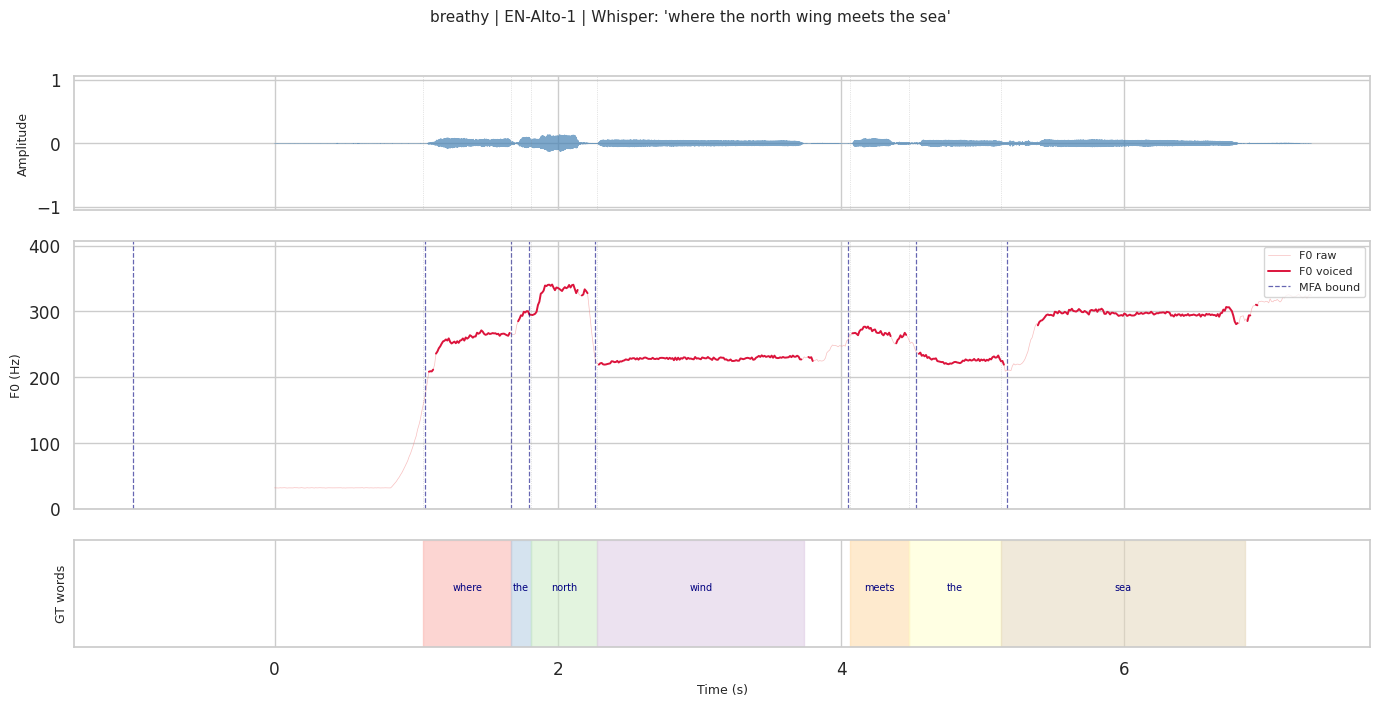

In [10]:
plot_track(
    track_1, contour_1, orig_words_1, mfa_words_1,
    title=f'{track_1.technique} | {track_1.singer_id} | Whisper: {hyp_1!r}'
)


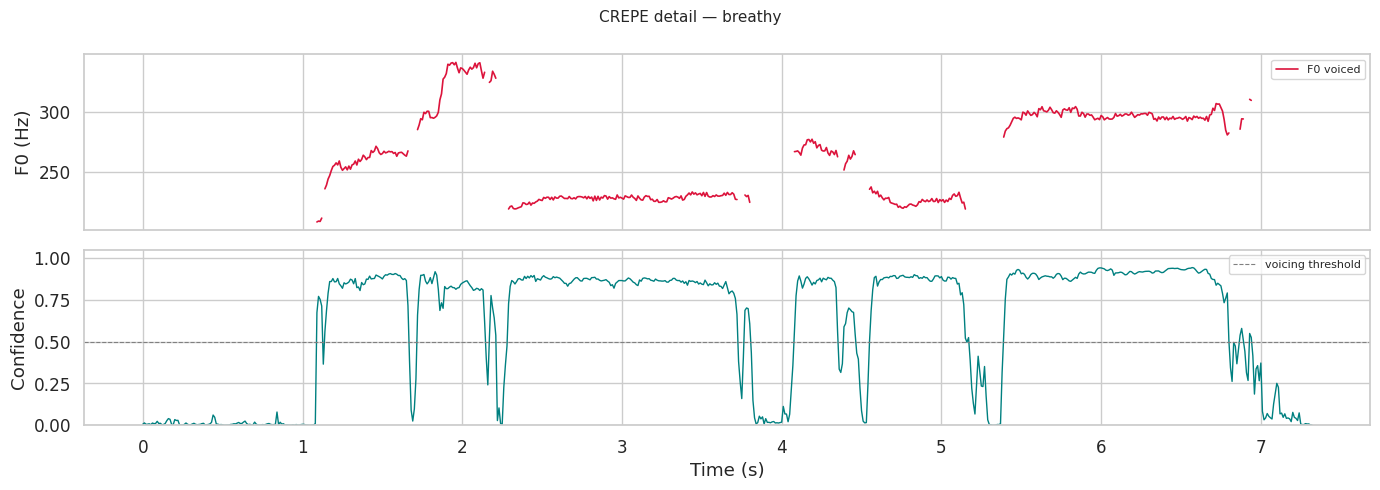

In [11]:
# Detailed pitch confidence plot
if contour_1 is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    voiced = contour_1.f0_voiced.copy()
    voiced[voiced == 0] = np.nan
    ax1.plot(contour_1.time, voiced, lw=1.2, color='crimson', label='F0 voiced')
    ax1.set_ylabel('F0 (Hz)')
    ax1.legend(fontsize=8)
    ax2.plot(contour_1.time, contour_1.confidence, lw=1.0, color='teal')
    ax2.axhline(0.5, ls='--', color='gray', lw=0.8, label='voicing threshold')
    ax2.set_ylabel('Confidence')
    ax2.set_xlabel('Time (s)')
    ax2.legend(fontsize=8)
    ax2.set_ylim(0, 1.05)
    fig.suptitle(f'CREPE detail — {track_1.technique}', fontsize=11)
    plt.tight_layout()
    plt.show()


---
## Part 2 — One track per (technique × group) combination

Run all three tools on one representative track per available (technique, group) pair and compare the results side by side.

In [12]:
print(f'Running Whisper on {len(tracks_5)} tracks...')
p2_asr = run_whisper(tracks_5)

print(f'Running CREPE on {len(tracks_5)} tracks...')
p2_pitch = run_crepe(tracks_5)

print(f'Running MFA on {len(tracks_5)} tracks...')
p2_mfa = run_mfa(tracks_5, sub='part2')

print('Done.')


Running Whisper on 9 tracks...


ASR WhisperHF: 100%|██████████| 3/3 [00:00<00:00,  8.16batch/s, utt=9/9]


Running CREPE on 9 tracks...
Running MFA on 9 tracks...
  $ /home/antonello/miniforge3/envs/aligner/bin/mfa validate /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part2/mfa_corpus english_mfa --ignore_acoustics --clean
  $ /home/antonello/miniforge3/envs/aligner/bin/mfa align --clean /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part2/mfa_corpus english_mfa english_mfa /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part2/mfa_output
Done.


### 2a — Transcription comparison


In [13]:
rows_asr = []
for u in tracks_5:
    hyp = p2_asr.get(u.utt_id, '')
    ref = clean_text(u.text)
    rows_asr.append({
        'technique': u.technique,
        'singer':    u.singer_id,
        'reference': ref,
        'hypothesis': hyp,
        'WER':       compute_wer(ref, hyp),
    })

df_asr_5 = pd.DataFrame(rows_asr)
display(df_asr_5.style
    .format({'WER': '{:.4f}'})
    .background_gradient(subset=['WER'], cmap='RdYlGn_r', vmin=0, vmax=1)
)


,technique,singer,reference,hypothesis,WER
0,breathy,EN-Alto-1,where the north wind meets the sea,where the north wing meets the sea,0.1429
1,breathy,EN-Alto-1,where the north wind meets the sea,where the north wind meets the sea,0.0000
2,breathy,EN-Alto-1,where the north wind meets the sea,where the north wing meets the sea?,0.1429
3,glissando,EN-Alto-1,the window is open sos that door i didnt know they did that anymore,the windows open so sad or i didn't know they'd be there anymore,0.5714
4,glissando,EN-Alto-1,the window is open sos that door i didnt know they did that anymore,"the windows open, so that door, i didn't know that they'd that anymore.",0.3571
5,glissando,EN-Alto-1,the window is open sos that door i didnt know they did that anymore,the window is open so that i didn't know they did that anymore.,0.1429
6,mixed_falsetto,EN-Alto-1,im years old i am pretty im,"i'm forty years old, i am pretty.",0.2857
7,mixed_falsetto,EN-Alto-1,im years old i am pretty im,"i'm 40 years old, i am pretty. i'm",0.0000
8,mixed_falsetto,EN-Alto-1,im years old i am pretty im,i'm 40 years old. i'm pretty. i'm a,0.4286


### 2b — TextGrid timing diff per technique


In [14]:
for u in tracks_5:
    if u.utt_id not in p2_mfa:
        print(f'[MFA] no result for {u.technique}/{u.group}')
        continue
    if not u.textgrid_path:
        print(f'[TextGrid] no original TextGrid for {u.technique}/{u.group} — skipping diff')
        continue
    orig_w, _ = parse_textgrid(u.textgrid_path)
    mfa_w     = p2_mfa[u.utt_id].words
    df_d      = textgrid_diff(orig_w, mfa_w)
    if df_d.empty:
        continue
    mae_s = df_d['delta_start'].abs().mean()
    mae_e = df_d['delta_end'].abs().mean()
    print(f'\n── {u.technique} / {u.group} ({u.singer_id}) ── MAE start: {mae_s:.4f} s  |  MAE end: {mae_e:.4f} s')
    display(df_d[['word', 'orig_start', 'orig_end', 'mfa_start', 'mfa_end',
                  'delta_start', 'delta_end', 'delta_dur']].style
        .format({'orig_start': '{:.4f}', 'orig_end': '{:.4f}',
                 'mfa_start':  '{:.4f}', 'mfa_end':  '{:.4f}',
                 'delta_start': '{:+.4f}', 'delta_end': '{:+.4f}', 'delta_dur': '{:+.4f}'})
        .background_gradient(subset=['delta_start', 'delta_end'],
                             cmap='RdYlGn_r', vmin=-0.3, vmax=0.3)
    )



── breathy / technique (EN-Alto-1) ── MAE start: 0.0199 s  |  MAE end: 0.0827 s


,word,orig_start,orig_end,mfa_start,mfa_end,delta_start,delta_end,delta_dur
0,where,1.0500,1.6700,1.0600,1.6700,+0.0100,+0.0000,-0.0100
1,the,1.6700,1.8100,1.6700,1.8000,+0.0000,-0.0100,-0.0100
2,north,1.8100,2.2800,1.8000,2.2600,-0.0100,-0.0200,-0.0100
3,wind,2.2800,3.7400,2.2600,3.7600,-0.0200,+0.0200,+0.0400
4,meets,4.0610,4.4810,4.0500,4.5300,-0.0110,+0.0490,+0.0600
5,the,4.4810,5.1310,4.5300,5.1400,+0.0490,+0.0090,-0.0400
6,sea,5.1310,6.8510,5.1700,7.3220,+0.0390,+0.4710,+0.4320



── breathy / control (EN-Alto-1) ── MAE start: 0.4921 s  |  MAE end: 0.5451 s


,word,orig_start,orig_end,mfa_start,mfa_end,delta_start,delta_end,delta_dur
0,where,2.5700,3.2510,2.5800,3.2000,+0.0100,-0.0510,-0.0610
1,the,3.2510,3.3310,3.2000,3.3300,-0.0510,-0.0010,+0.0500
2,north,3.3310,3.8510,3.3300,3.8300,-0.0010,-0.0210,-0.0200
3,wind,3.8510,5.4270,3.8300,4.0200,-0.0210,-1.4070,-1.3860
4,meets,5.6960,6.2340,4.0200,5.4400,-1.6760,-0.7940,+0.8820
5,the,6.2340,6.9620,5.7000,5.8100,-0.5340,-1.1520,-0.6180
6,sea,6.9620,8.5720,5.8100,8.9620,-1.1520,+0.3900,+1.5420



── breathy / speech (EN-Alto-1) ── MAE start: 0.0614 s  |  MAE end: 0.0357 s


...

,word,orig_start,orig_end,mfa_start,mfa_end,delta_start,delta_end,delta_dur
0,i'm,3.8500,4.2900,3.8900,4.2300,+0.0400,-0.0600,-0.1000
1,years,4.8910,5.8410,4.2300,4.4400,-0.6610,-1.4010,-0.7400
2,old,5.8410,6.2810,4.4400,4.8100,-1.4010,-1.4710,-0.0700
3,i,6.2810,6.6110,4.8100,6.9900,-1.4710,+0.3790,+1.8500
4,am,6.6110,7.1410,6.9900,7.1500,+0.3790,+0.0090,-0.3700
5,pretty,7.1410,8.7410,7.1500,8.7400,+0.0090,-0.0010,-0.0100
6,i'm,9.4520,9.9920,9.4500,10.0800,-0.0020,+0.0880,+0.0900



── mixed_falsetto / control (EN-Alto-1) ── MAE start: 1.4099 s  |  MAE end: 1.4787 s


,word,orig_start,orig_end,mfa_start,mfa_end,delta_start,delta_end,delta_dur
0,i'm,0.8700,2.0260,0.8500,1.2000,-0.0200,-0.8260,-0.8060
1,years,2.0260,2.7300,1.2000,1.3800,-0.8260,-1.3500,-0.5240
2,old,2.7300,3.3500,1.3800,1.8600,-1.3500,-1.4900,-0.1400
3,i,3.3500,3.5110,1.8600,2.5100,-1.4900,-1.0010,+0.4890
4,am,3.5110,4.0610,2.5100,2.5700,-1.0010,-1.4910,-0.4900
5,pretty,4.0610,5.9710,2.5700,2.7600,-1.4910,-3.2110,-1.7200
6,i'm,6.4510,7.0020,2.7600,6.0200,-3.6910,-0.9820,+2.7090



── mixed_falsetto / speech (EN-Alto-1) ── MAE start: 0.0157 s  |  MAE end: 0.0349 s


,word,orig_start,orig_end,mfa_start,mfa_end,delta_start,delta_end,delta_dur
0,i'm,0.7200,0.9000,0.7100,0.9900,-0.0100,+0.0900,+0.1000
1,years,1.2200,1.8100,1.2800,1.8100,+0.0600,+0.0000,-0.0600
2,old,1.8100,2.1700,1.8100,2.1400,+0.0000,-0.0300,-0.0300
3,i,2.1700,2.2600,2.1700,2.2600,+0.0000,+0.0000,+0.0000
4,am,2.2600,2.4000,2.2600,2.4200,+0.0000,+0.0200,+0.0200
5,pretty,2.4000,3.0000,2.4200,2.9500,+0.0200,-0.0500,-0.0700
6,i'm,3.0000,3.2840,2.9800,3.2300,-0.0200,-0.0540,-0.0340


### 2c — Pitch curves (one panel per technique)


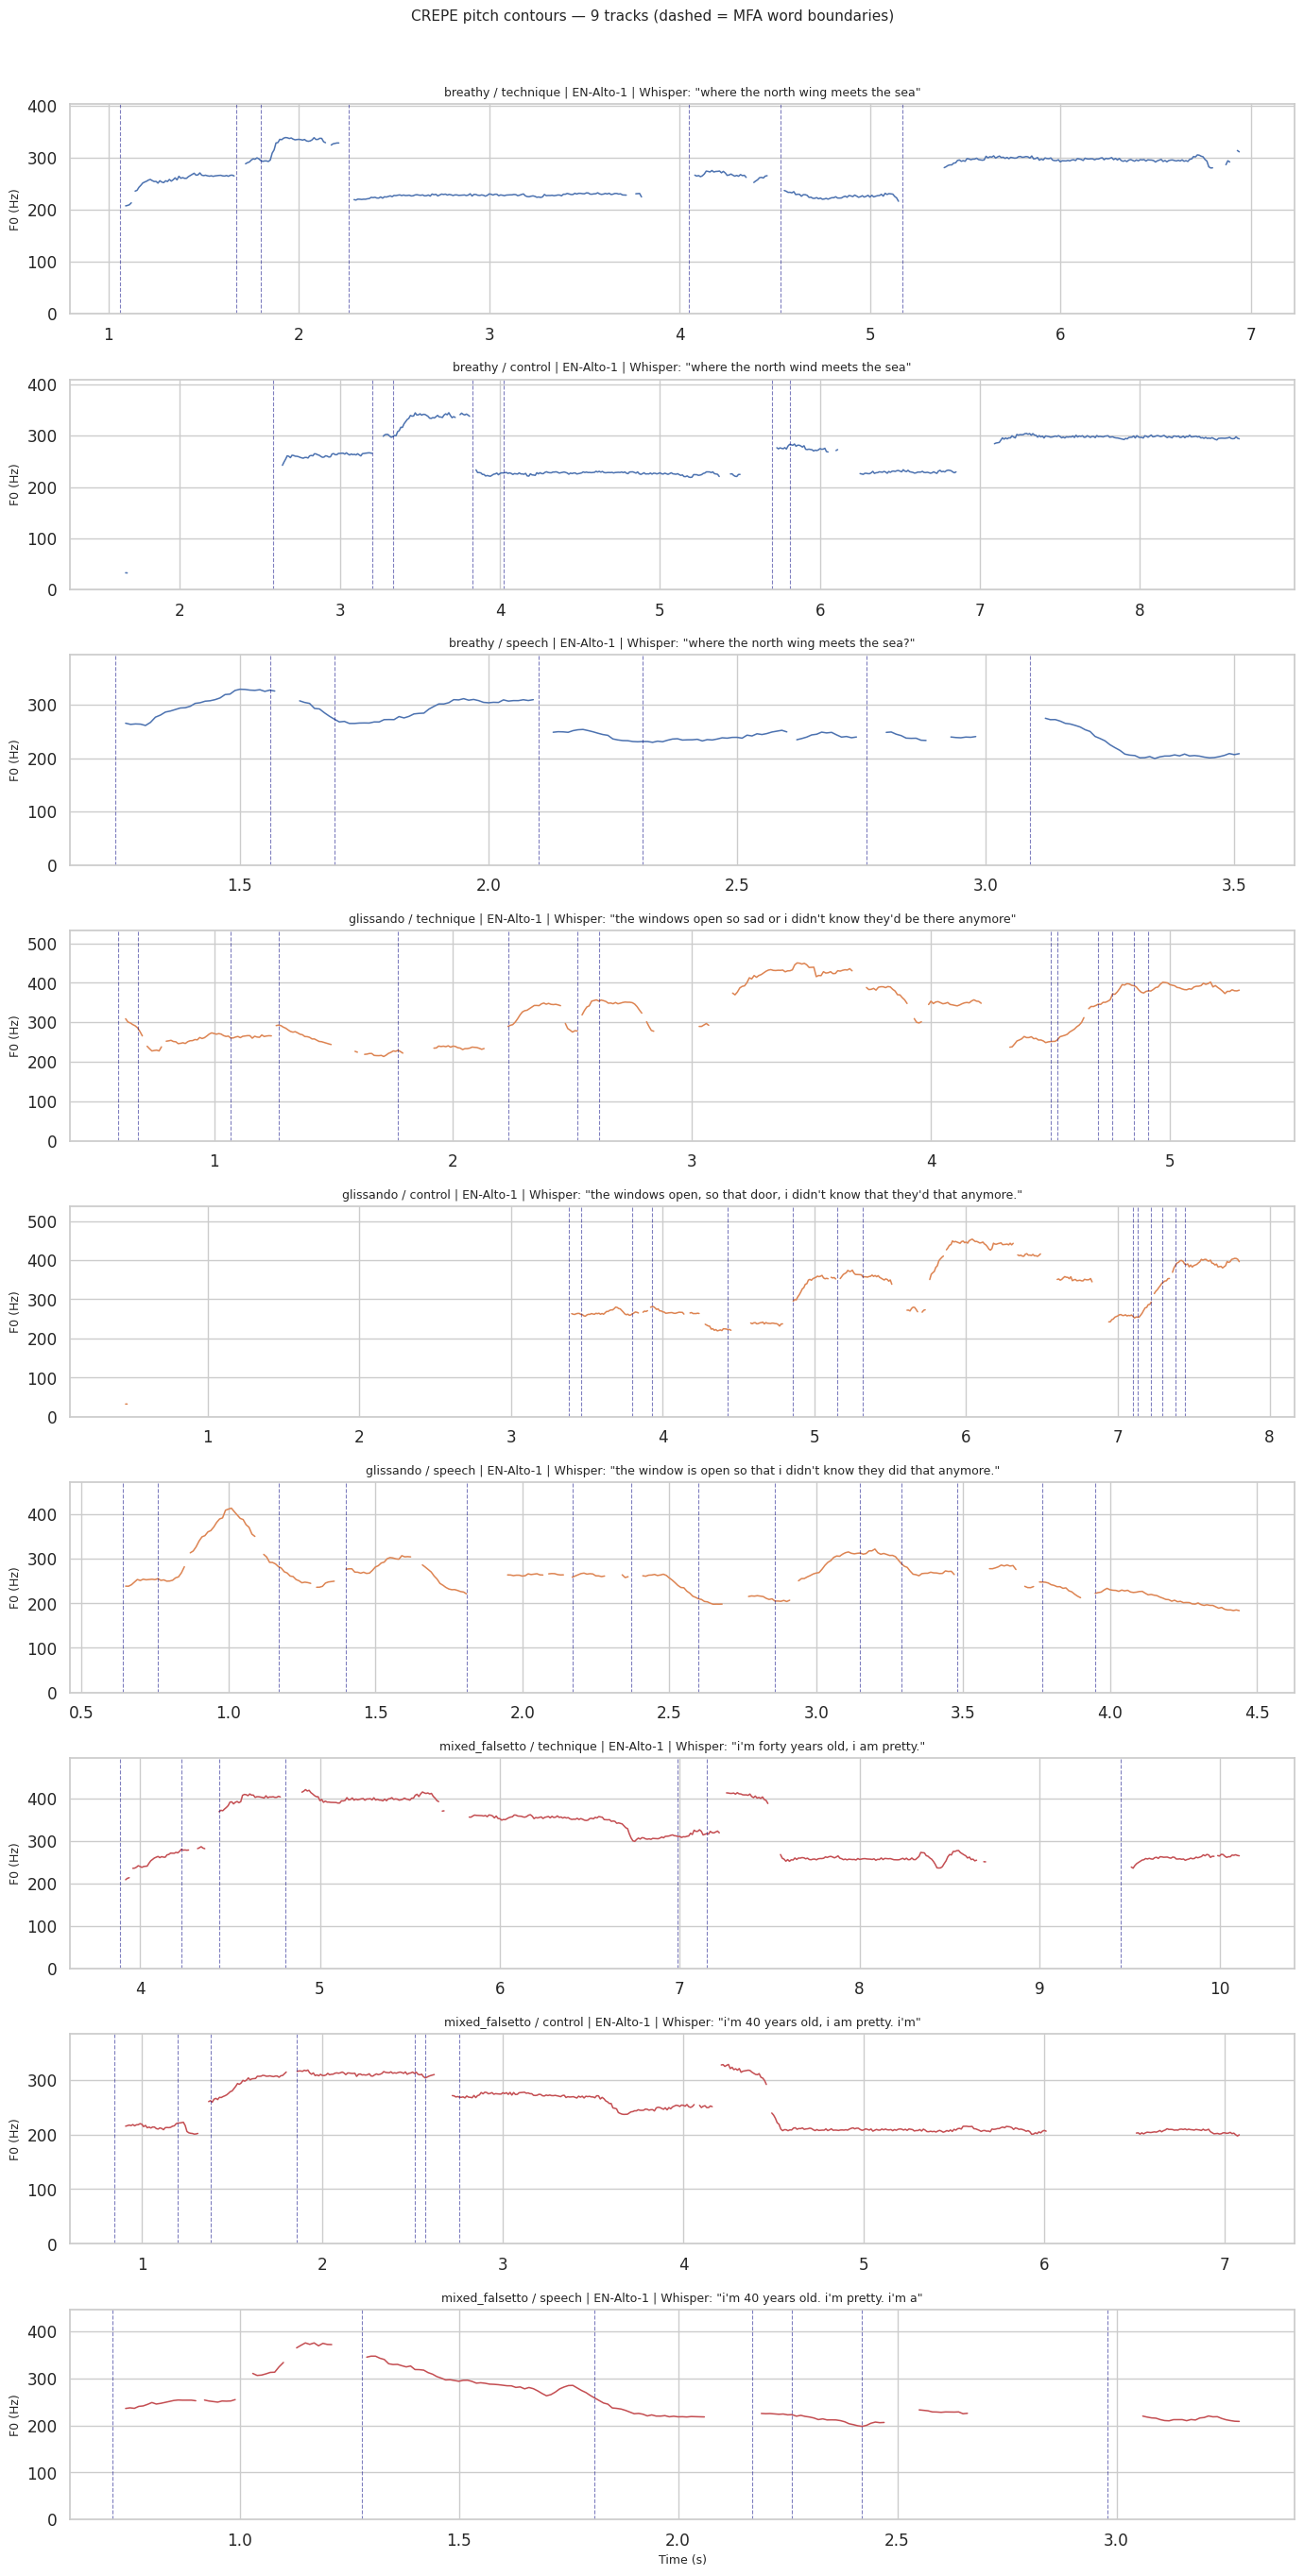

In [15]:
fig, axes = plt.subplots(len(tracks_5), 1, figsize=(14, 3 * len(tracks_5)), sharex=False)
if len(tracks_5) == 1:
    axes = [axes]

for ax, u in zip(axes, tracks_5):
    contour = p2_pitch.get(u.utt_id)
    color   = TECH_COLORS.get(u.technique, 'steelblue')
    if contour is not None:
        voiced = contour.f0_voiced.copy()
        voiced[voiced == 0] = np.nan
        ax.plot(contour.time, voiced, lw=1.1, color=color)
        cap = np.nanpercentile(contour.frequency[contour.frequency > 0], 99) * 1.2
        ax.set_ylim(0, min(1200, cap))
    else:
        ax.text(0.5, 0.5, 'CREPE N/A', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    if u.utt_id in p2_mfa:
        for w in p2_mfa[u.utt_id].words:
            if w.label not in SKIP_LABELS:
                ax.axvline(w.start, color='navy', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('F0 (Hz)', fontsize=9)
    asr_text = p2_asr.get(u.utt_id, '—')
    ax.set_title(f'{u.technique} / {u.group} | {u.singer_id} | Whisper: "{asr_text}"', fontsize=9)

axes[-1].set_xlabel('Time (s)', fontsize=9)
fig.suptitle(f'CREPE pitch contours — {len(tracks_5)} tracks (dashed = MFA word boundaries)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


In [16]:
# Pitch statistics table
rows_pitch = []
for u in tracks_5:
    s = pitch_stats(p2_pitch.get(u.utt_id))
    rows_pitch.append({'technique': u.technique, 'singer': u.singer_id, **s})

df_pitch_5 = pd.DataFrame(rows_pitch)
display(df_pitch_5.style.format({
    'f0_mean_hz': '{:.1f}', 'f0_std_hz': '{:.1f}',
    'f0_range_st': '{:.2f}', 'voiced_ratio': '{:.3f}', 'vibrato_index': '{:.3f}'
}).background_gradient(cmap='YlOrRd', subset=['f0_range_st', 'vibrato_index', 'voiced_ratio']))


,technique,singer,f0_mean_hz,f0_std_hz,f0_range_st,voiced_ratio,vibrato_index
0,breathy,EN-Alto-1,263.3,35.7,8.48,0.679,7.167
1,breathy,EN-Alto-1,264.5,39.9,40.91,0.582,8.081
2,breathy,EN-Alto-1,258.4,35.1,8.67,0.531,12.267
3,glissando,EN-Alto-1,323.1,67.0,12.91,0.705,18.526
4,glissando,EN-Alto-1,328.5,73.3,45.70,0.470,18.245
5,glissando,EN-Alto-1,260.6,45.2,14.05,0.664,16.954
6,mixed_falsetto,EN-Alto-1,320.7,61.0,12.16,0.475,10.618
7,mixed_falsetto,EN-Alto-1,249.3,42.2,8.80,0.737,6.705
8,mixed_falsetto,EN-Alto-1,256.8,46.7,11.08,0.565,13.305


---
## Part 3 — Two tracks per (technique × group) combination

Aggregate statistics and distribution plots across a broader sample — two tracks per (technique, group) pair.

In [17]:
print(f'Running Whisper on {len(tracks_10)} tracks...')
p3_asr = run_whisper(tracks_10)

print(f'Running CREPE on {len(tracks_10)} tracks...')
p3_pitch = run_crepe(tracks_10)

print(f'Running MFA on {len(tracks_10)} tracks...')
p3_mfa = run_mfa(tracks_10, sub='part3')

print('Done.')


Running Whisper on 18 tracks...


ASR WhisperHF: 100%|██████████| 5/5 [00:00<00:00, 10.78batch/s, utt=18/18]


Running CREPE on 18 tracks...
Running MFA on 18 tracks...
  $ /home/antonello/miniforge3/envs/aligner/bin/mfa validate /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part3/mfa_corpus english_mfa --ignore_acoustics --clean
  $ /home/antonello/miniforge3/envs/aligner/bin/mfa align --clean /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part3/mfa_corpus english_mfa english_mfa /home/antonello/Desktop/thesis-alt-expressive/data/_work/notebook_probe/mfa_part3/mfa_output
Done.


### 3a — Full results table


In [18]:
rows_all = []
for u in tracks_10:
    hyp    = p3_asr.get(u.utt_id, '')
    ref    = clean_text(u.text)
    wer_v  = compute_wer(ref, hyp)
    pstats = pitch_stats(p3_pitch.get(u.utt_id))

    mae_start = mae_end = float('nan')
    if u.utt_id in p3_mfa and u.textgrid_path:
        orig_w, _ = parse_textgrid(u.textgrid_path)
        mfa_w     = p3_mfa[u.utt_id].words
        df_d      = textgrid_diff(orig_w, mfa_w)
        if not df_d.empty:
            mae_start = df_d['delta_start'].abs().mean()
            mae_end   = df_d['delta_end'].abs().mean()

    rows_all.append({
        'technique':     u.technique,
        'group':         u.group,
        'singer':        u.singer_id,
        'reference':     ref,
        'hypothesis':    hyp,
        'WER':           wer_v,
        'mfa_mae_start': round(mae_start, 4) if not np.isnan(mae_start) else float('nan'),
        'mfa_mae_end':   round(mae_end,   4) if not np.isnan(mae_end)   else float('nan'),
        **pstats,
    })

df_all = pd.DataFrame(rows_all)
display(df_all[['technique', 'group', 'singer', 'WER', 'mfa_mae_start', 'mfa_mae_end',
               'f0_mean_hz', 'f0_range_st', 'voiced_ratio', 'vibrato_index']].style
    .format({'WER': '{:.4f}', 'mfa_mae_start': '{:.4f}', 'mfa_mae_end': '{:.4f}',
             'f0_mean_hz': '{:.1f}', 'f0_range_st': '{:.2f}',
             'voiced_ratio': '{:.3f}', 'vibrato_index': '{:.3f}'})
    .background_gradient(subset=['WER'], cmap='RdYlGn_r', vmin=0, vmax=1)
)


,technique,group,singer,WER,mfa_mae_start,mfa_mae_end,f0_mean_hz,f0_range_st,voiced_ratio,vibrato_index
0,breathy,technique,EN-Alto-1,0.1429,0.0184,0.0827,263.3,8.55,0.679,7.299
1,breathy,technique,EN-Alto-1,0.0000,0.0378,0.0211,297.7,13.23,0.767,8.765
2,breathy,control,EN-Alto-1,0.0000,0.4893,0.5451,264.4,40.94,0.582,8.164
3,breathy,control,EN-Alto-1,0.0000,0.1054,0.1268,295.4,13.05,0.823,7.781
4,breathy,speech,EN-Alto-1,0.1429,0.0614,0.0357,258.4,8.71,0.531,12.157
5,breathy,speech,EN-Alto-1,0.0833,0.0388,0.0128,249.2,8.52,0.760,14.523
6,glissando,technique,EN-Alto-1,0.5714,0.4431,0.4352,323.1,12.79,0.705,18.406
7,glissando,technique,EN-Alto-1,0.3333,0.3223,0.2376,349.4,16.37,0.727,17.980
8,glissando,control,EN-Alto-1,0.3571,0.4496,0.4513,328.5,45.76,0.470,18.158
9,glissando,control,EN-Alto-1,0.2000,0.4011,0.3321,355.8,16.31,0.832,14.545


### 3b — WER per technique


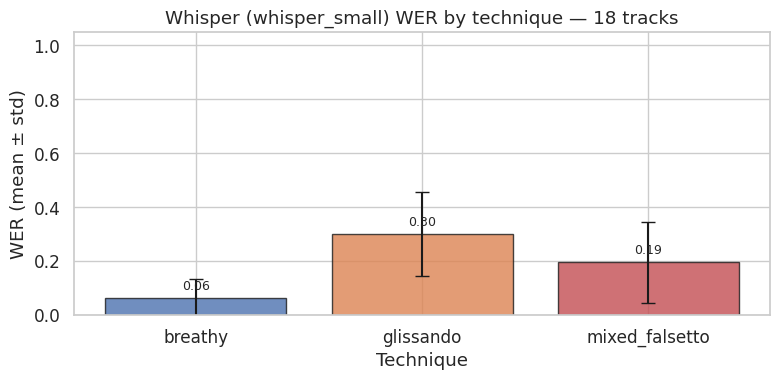

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
wer_by_tech = df_all.groupby('technique')['WER'].agg(['mean', 'std']).reset_index()
colors_bar  = [TECH_COLORS.get(t, 'gray') for t in wer_by_tech['technique']]
bars = ax.bar(wer_by_tech['technique'], wer_by_tech['mean'],
              yerr=wer_by_tech['std'], capsize=5, color=colors_bar, alpha=0.8, edgecolor='k')
ax.set_ylabel('WER (mean ± std)')
ax.set_xlabel('Technique')
ax.set_title(f'Whisper ({WHISPER_ID}) WER by technique — {len(tracks_10)} tracks')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, wer_by_tech['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### 3c — MFA boundary error distribution (violin)


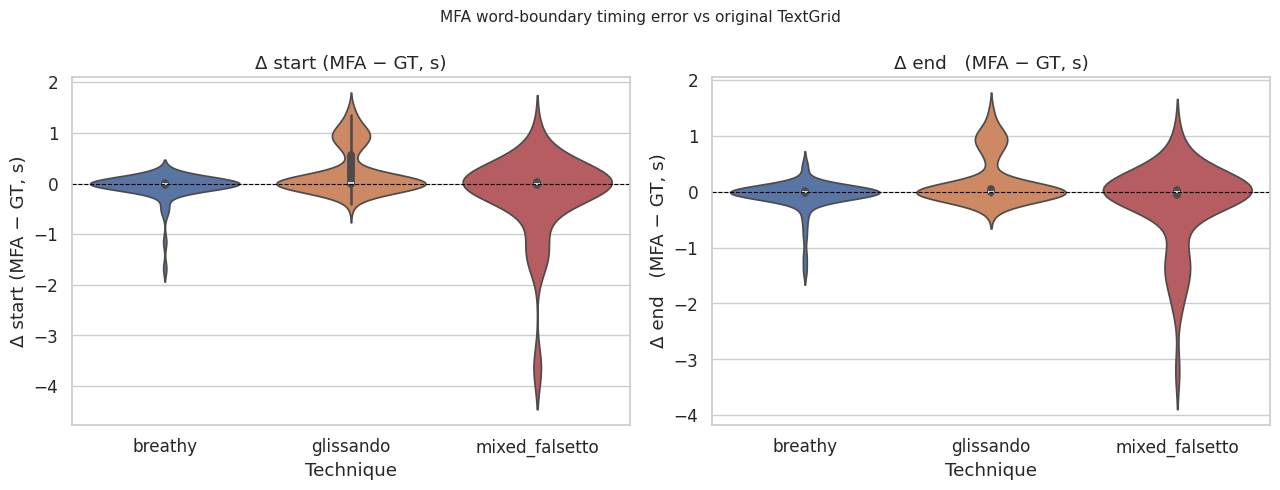

In [20]:
all_diff_rows = []
for u in tracks_10:
    if u.utt_id not in p3_mfa or not u.textgrid_path:
        continue
    orig_w, _ = parse_textgrid(u.textgrid_path)
    mfa_w     = p3_mfa[u.utt_id].words
    df_d      = textgrid_diff(orig_w, mfa_w)
    df_d['technique'] = u.technique
    df_d['group']     = u.group
    all_diff_rows.append(df_d)

if all_diff_rows:
    df_diffs = pd.concat(all_diff_rows, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, col, label in [
        (axes[0], 'delta_start', 'Δ start (MFA − GT, s)'),
        (axes[1], 'delta_end',   'Δ end   (MFA − GT, s)'),
    ]:
        order = [t for t in TECHNIQUES if t in df_diffs['technique'].unique()]
        pal   = {t: TECH_COLORS.get(t, 'gray') for t in order}
        sns.violinplot(data=df_diffs, x='technique', y=col, order=order,
                       palette=pal, inner='box', ax=ax)
        ax.axhline(0, ls='--', color='black', lw=0.8)
        ax.set_xlabel('Technique')
        ax.set_ylabel(label)
        ax.set_title(label)

    fig.suptitle('MFA word-boundary timing error vs original TextGrid', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('[TextGrid diff] no MFA+TextGrid results available for violin plot.')


### 3d — Pitch statistics heatmap


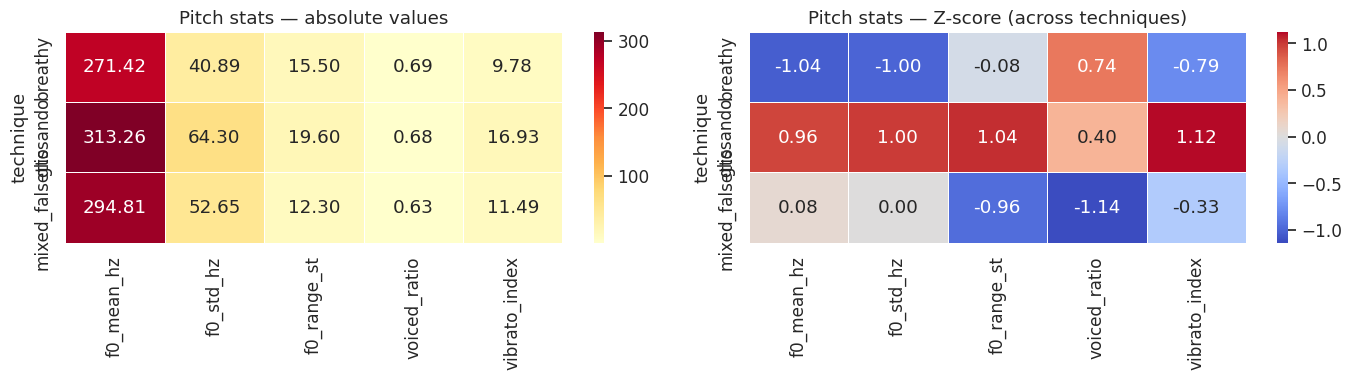

In [21]:
pitch_cols = ['f0_mean_hz', 'f0_std_hz', 'f0_range_st', 'voiced_ratio', 'vibrato_index']
df_pitch_heat = df_all.dropna(subset=['f0_mean_hz'])

if not df_pitch_heat.empty:
    pivot = df_pitch_heat.groupby('technique')[pitch_cols].mean()
    # Z-score across rows so different scales are comparable
    pivot_z = (pivot - pivot.mean()) / (pivot.std() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0])
    axes[0].set_title('Pitch stats — absolute values')

    sns.heatmap(pivot_z, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=axes[1])
    axes[1].set_title('Pitch stats — Z-score (across techniques)')

    plt.tight_layout()
    plt.show()
else:
    print('[Pitch heatmap] no CREPE results available.')


### 3e — Pitch curve grid (all 10 tracks)


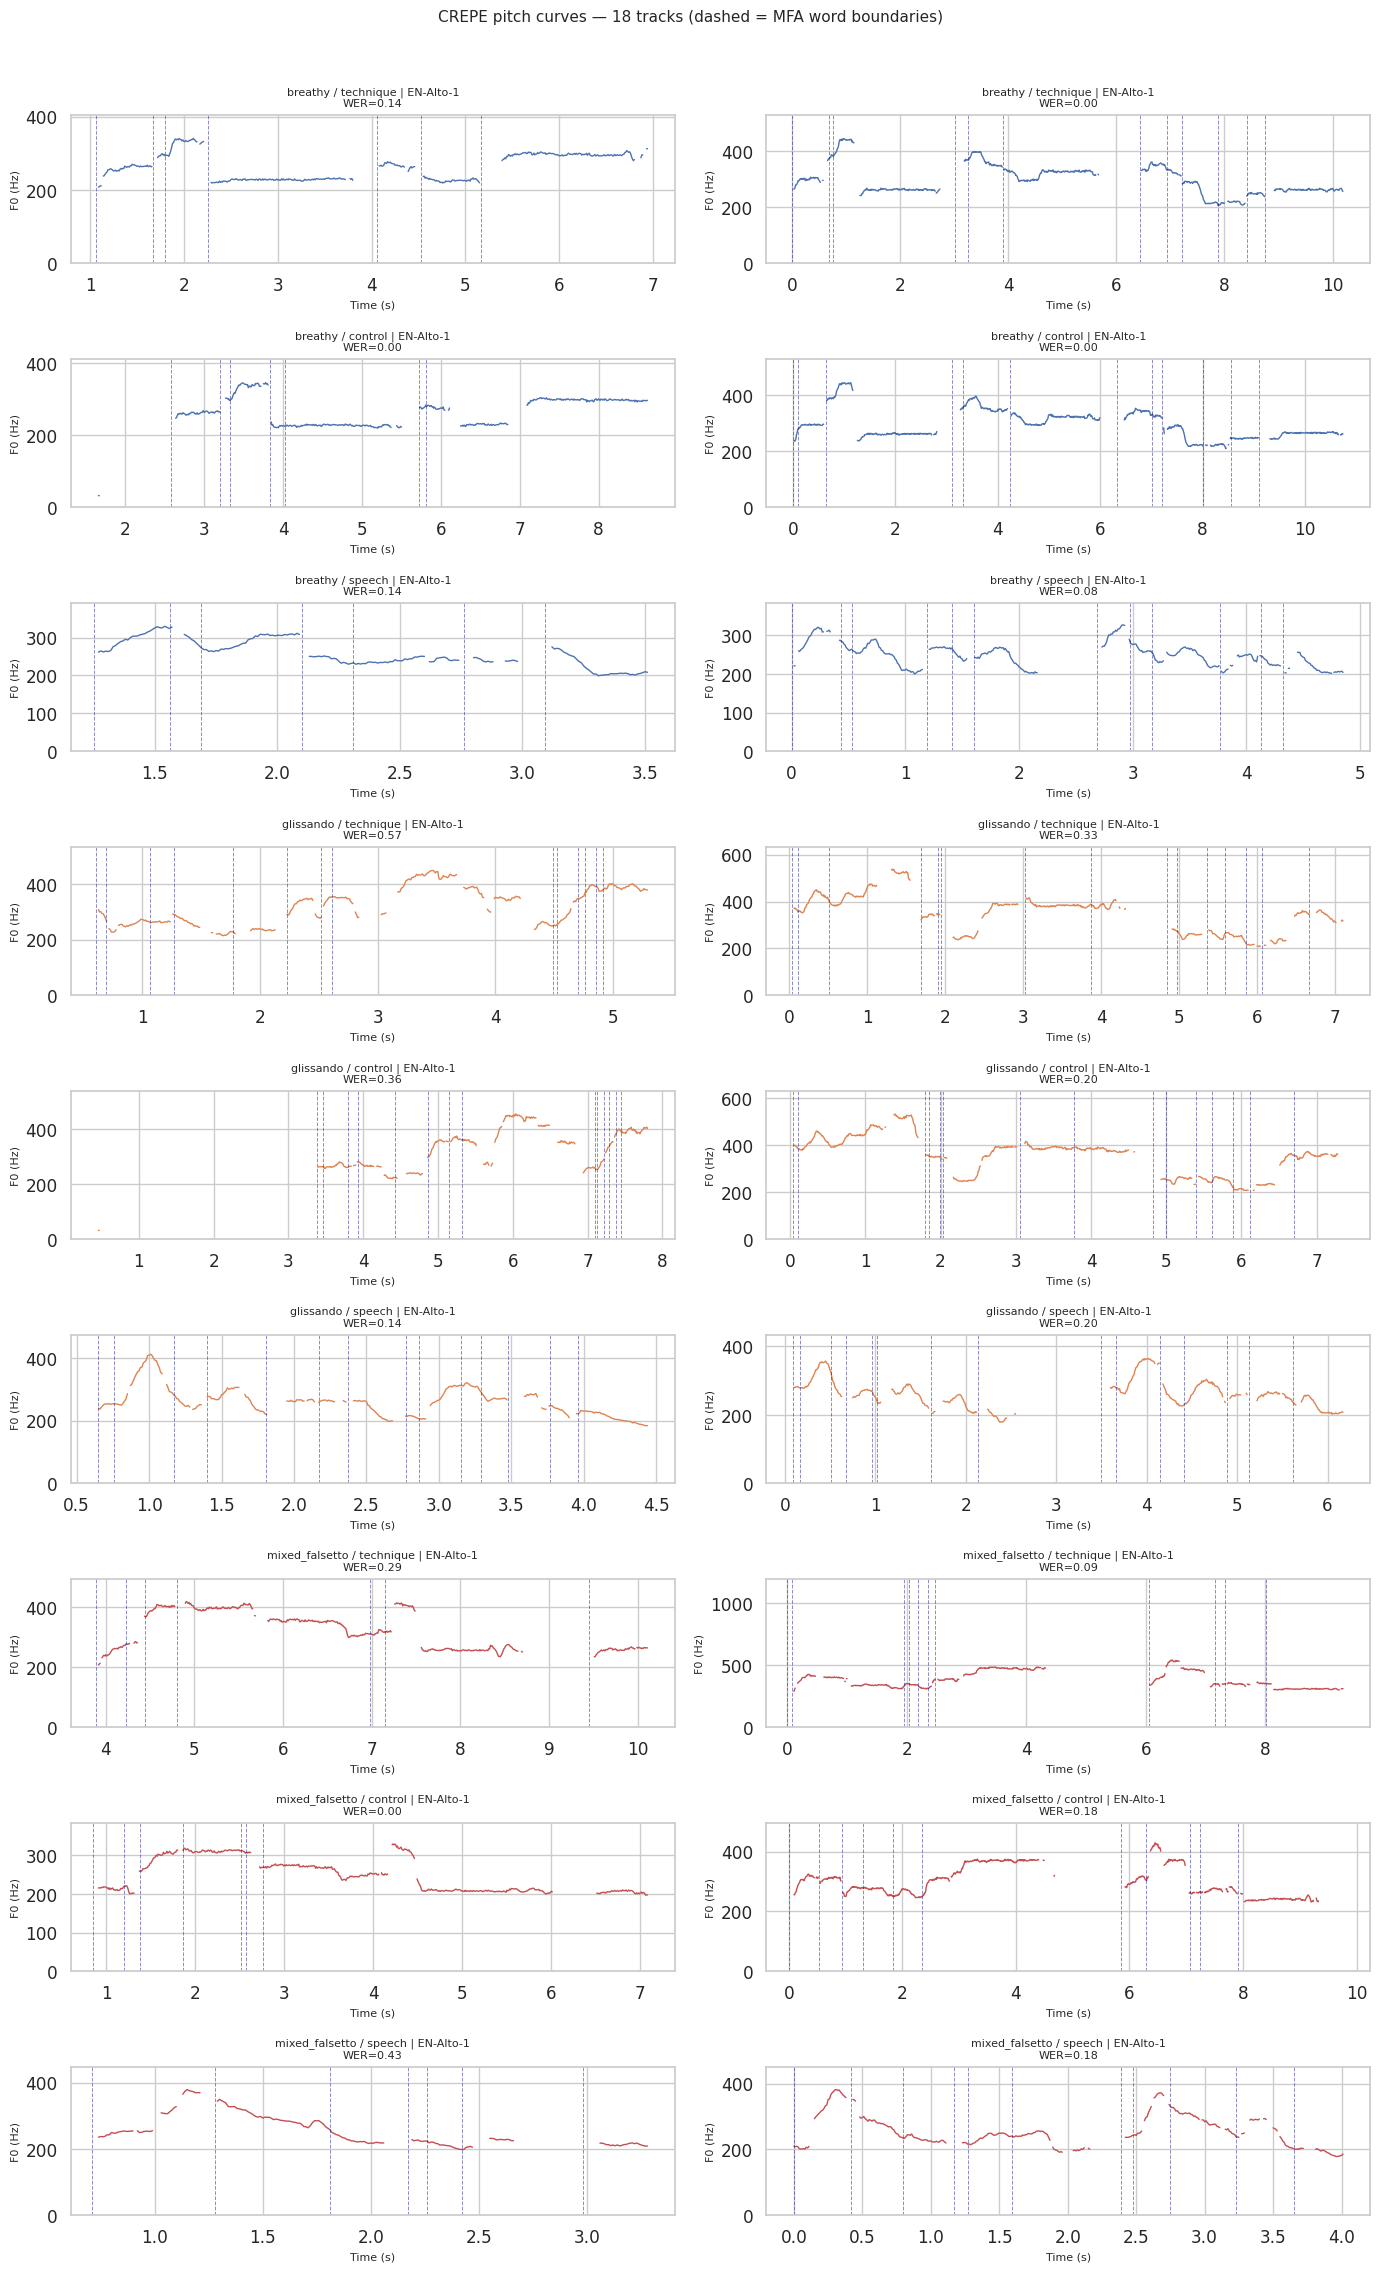

In [22]:
n    = len(tracks_10)
cols = 2
rows = max(1, (n + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 2.5 * rows))
axes = np.array(axes).flatten()

for i, u in enumerate(tracks_10):
    ax      = axes[i]
    contour = p3_pitch.get(u.utt_id)
    color   = TECH_COLORS.get(u.technique, 'steelblue')

    if contour is not None:
        voiced = contour.f0_voiced.copy()
        voiced[voiced == 0] = np.nan
        ax.plot(contour.time, voiced, lw=1.0, color=color)
        pos_f0 = contour.frequency[contour.frequency > 0]
        if len(pos_f0):
            ax.set_ylim(0, min(1200, np.percentile(pos_f0, 99) * 1.2))
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, color='gray')

    if u.utt_id in p3_mfa:
        for w in p3_mfa[u.utt_id].words:
            if w.label not in SKIP_LABELS:
                ax.axvline(w.start, color='navy', lw=0.7, ls='--', alpha=0.45)

    wer_val = compute_wer(clean_text(u.text), p3_asr.get(u.utt_id, ''))
    ax.set_title(f'{u.technique} / {u.group} | {u.singer_id}\nWER={wer_val:.2f}', fontsize=8)
    ax.set_ylabel('F0 (Hz)', fontsize=8)
    ax.set_xlabel('Time (s)', fontsize=8)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'CREPE pitch curves — {n} tracks (dashed = MFA word boundaries)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


---
## Summary

Run the cell below to print a compact summary of all three experiments.


In [23]:
print('=' * 60)
print('PART 1 — single track')
print(f'  Track     : {track_1.utt_id}')
print(f'  Technique : {track_1.technique}')
print(f'  Group     : {track_1.group}')
print(f'  Reference : {clean_text(track_1.text)!r}')
print(f'  Whisper   : {p1_asr.get(track_1.utt_id, "—")!r}')
print(f'  WER       : {compute_wer(clean_text(track_1.text), p1_asr.get(track_1.utt_id, "")):.4f}')
if contour_1 is not None:
    s = pitch_stats(contour_1)
    print(f'  F0 mean   : {s.get("f0_mean_hz", float("nan")):.1f} Hz')
    print(f'  Voiced    : {s.get("voiced_ratio", float("nan")):.3f}')

print()
print('=' * 60)
print(f'PART 2 — {len(tracks_5)} tracks (one per technique×group, mean WER by technique)')
for _, row in df_asr_5.iterrows():
    print(f'  {row["technique"]:<18s} WER={row["WER"]:.4f}  hyp={row["hypothesis"]!r}')

print()
print('=' * 60)
print(f'PART 3 — {len(tracks_10)} tracks aggregate')
agg_cols = [c for c in ['WER', 'mfa_mae_start', 'mfa_mae_end', 'f0_mean_hz', 'voiced_ratio']
            if c in df_all.columns]
agg = df_all.groupby('technique')[agg_cols].mean()
print(agg.round(4).to_string())


PART 1 — single track
  Track     : EN-Alto-1__breathy__technique__all_is_found__0000
  Technique : breathy
  Group     : technique
  Reference : 'where the north wind meets the sea'
  Whisper   : 'where the north wing meets the sea'
  WER       : 0.1429
  F0 mean   : 263.3 Hz
  Voiced    : 0.679

PART 2 — 9 tracks (one per technique×group, mean WER by technique)
  breathy            WER=0.1429  hyp='where the north wing meets the sea'
  breathy            WER=0.0000  hyp='where the north wind meets the sea'
  breathy            WER=0.1429  hyp='where the north wing meets the sea?'
  glissando          WER=0.5714  hyp="the windows open so sad or i didn't know they'd be there anymore"
  glissando          WER=0.3571  hyp="the windows open, so that door, i didn't know that they'd that anymore."
  glissando          WER=0.1429  hyp="the window is open so that i didn't know they did that anymore."
  mixed_falsetto     WER=0.2857  hyp="i'm forty years old, i am pretty."
  mixed_falsetto    